In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
import matplotlib.pyplot as plt
import joblib
import os
import ast

PREDICTORS = ["PwmD", "PwmE", "sPwm", "dPwm"]   
TARGET_INT = ["Theta"]  
TARGET = ["DeltaTheta"]
     
INPUT_SIZE = len(PREDICTORS)  
OUTPUT_SIZE = len(TARGET)   
     
TIME_STEPS = 5
TS = 0.07

In [2]:
TITLES = ["Train_1", "Train_2", "Test_1", "Test_2", "Test_3", "Val", "LSG_1", "LSG_2"]

Datasets = []
NormDatasets = []

# Ler Datasets.xlsx
for title in TITLES:
    df = pd.read_excel("./Data/Datasets.xlsx", sheet_name=title)
    Datasets.append(df)

# Ler NormDatasets.xlsx
for title in TITLES:
    df = pd.read_excel("./Data/NormDatasets.xlsx", sheet_name=title)
    NormDatasets.append(df)
    
OUT_SCALER = joblib.load("./scalers/out_scaler.pkl")

In [3]:
results = pd.read_excel("resultados.xlsx")
results.head()

,model,Neurons,Ld,Lp,reg,seed,R2_Train_1_Theta,MSE_Train_1_Theta,R2_Train_2_Theta,MSE_Train_2_Theta,R2_Val_Theta,MSE_Val_Theta,R2_Test_1_Theta,MSE_Test_1_Theta,R2_Test_2_Theta,MSE_Test_2_Theta,R2_Test_3_Theta,MSE_Test_3_Theta
0,model_arch16_r0.01_seed8326,[16],0.3,0.7,0.01,8326,[0.7323455469332127],[0.0610392738710846],[0.3744234321897685],[0.14232517540774706],[-2.440864298944629],[1.124651355272803],[0.4397234351795921],[0.1286105831989393],[0.8378103605484954],[0.038332477941360826],[0.6410627465959343],[0.1178839133771609]
1,model_arch16_r0.01_seed8220,[16],0.3,0.7,0.01,8220,[0.7127629106315648],[0.06550514352742043],[0.33397512820807596],[0.15152758524111312],[-2.5834175672509723],[1.1712450923313875],[0.46795734594997984],[0.12212953444879154],[0.8175916331828724],[0.043111044090013456],[0.6397746900318744],[0.11830694316017316]
2,model_arch16_r0.01_seed1444,[16],0.3,0.7,0.01,1444,[0.7566231225126879],[0.05550271145733777],[0.4338841751118706],[0.1287972379789425],[-2.8094684824808946],[1.2451301532016945],[0.5885233655227694],[0.09445379881240716],[0.840322064707028],[0.037738852820929134],[0.6264445201285632],[0.1226849022025459]
3,model_arch16_r0.01_seed1595,[16],0.3,0.7,0.01,1595,[0.7773854092144197],[0.05076781954854986],[0.46035371252057933],[0.12277514292534517],[-2.732185377064008],[1.2198700610575632],[0.5259841209257644],[0.10880958169798995],[0.8600407732651624],[0.033078462900876224],[0.6589562788301508],[0.11200723274870787]
4,model_arch16_r0.01_seed5803,[16],0.3,0.7,0.01,5803,[0.6917846858131222],[0.07028928066898552],[0.38200777577846246],[0.14059965836130148],[-3.333061931341544],[1.4162674113765383],[0.3335725444486032],[0.15297734922345693],[0.8557847746512388],[0.034084340795040156],[0.6086191846505649],[0.12853918532161152]


In [4]:
def BuildModel(architecture, r):

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(TIME_STEPS, INPUT_SIZE)))

    for i, units in enumerate(architecture):

        if i < len(architecture) - 1:
            model.add(
                tf.keras.layers.SimpleRNN(
                    units,
                    activation="tanh",
                    return_sequences=True,
                    kernel_regularizer=tf.keras.regularizers.l2(r)
                )
            )
        else:
            model.add(
                tf.keras.layers.SimpleRNN(
                    units,
                    activation="tanh",
                    kernel_regularizer=tf.keras.regularizers.l2(r)
                )
            )

    model.add(tf.keras.layers.Dense(OUTPUT_SIZE))

    return model

In [5]:
def LoadModelFromRow(row):

    # arquitetura
    arch = row["Neurons"]
    if isinstance(arch, str):
        arch = ast.literal_eval(arch)

    r = float(row["reg"])
    model_name = row["model"]

    weights_path = f"weights/{model_name}.weights.h5"

    # build
    model = BuildModel(arch, r)
    model.build((None, TIME_STEPS, INPUT_SIZE))

    # load pesos
    model.load_weights(weights_path)

    return model

In [6]:
def CreateSequences(input_data, target_data, timesteps):
    X_seq, Y_seq = [], []
    
    for i in range(timesteps, len(input_data)):
        X_seq.append(input_data.iloc[i-timesteps:i].values)
        Y_seq.append(target_data.iloc[i])
    return np.array(X_seq), np.array(Y_seq)


In [7]:
R = tf.constant(0.0341, dtype=tf.float32)
L = tf.constant(0.0606, dtype=tf.float32)
dt = tf.constant(TS, dtype=tf.float32)

def CinematicModel(Wd, We, theta):

    dtheta_cin = (R / (2 * L)) * (Wd - We)
    # dx_cin = (R / 2) * tf.cos(theta) * (Wd + We)
    # dy_cin = (R / 2) * tf.sin(theta) * (Wd + We)

    # return [dtheta_cin, dx_cin, dy_cin]
    return [dtheta_cin]


def NumericalIntegration(dataset, dq):

    q = [None] * OUTPUT_SIZE

    init_vals = np.array([
        dataset[name].iloc[0] for name in TARGET_INT
    ])

    for j in range(OUTPUT_SIZE):
        q[j] = init_vals[j] + np.cumsum(dq[j] * TS)

    return q

def GetCin(dataset): 
    dq = CinematicModel(tf.convert_to_tensor(dataset["Wd"].values, dtype=tf.float32),
                        tf.convert_to_tensor(dataset["We"].values, dtype=tf.float32), 
                        tf.convert_to_tensor(dataset["Theta"].values, dtype=tf.float32))
    q = NumericalIntegration(dataset, dq)
    return np.vstack(q).T

In [8]:
def PlotOut(ax, title, target_name, y_true, y_pred, y_cin):
    time = (np.arange(0, len(y_pred), 1).astype(float) * 0.07).round(5)

    ax.plot(time, y_true, linestyle='-', linewidth=1.5, color='tab:blue', label='Amostras Reais')
    ax.plot(time, y_pred, linestyle='--', linewidth=1.5, color='tab:orange', label='Valores preditos')
    ax.plot(time, y_cin, linestyle=':', linewidth=2, color='tab:green', label='Modelo Cinemático')

    ax.set_title(f'{title} - {target_name}')
    ax.set_xlabel('Tempo [s]')
    ax.set_ylabel(target_name)
    ax.legend()
    ax.grid(True)


def EvalModel(model):
    n_datasets = len(Datasets)
    n_targets = len(TARGET)
    fig, axs = plt.subplots(n_datasets, n_targets, figsize=(6 * n_targets, 4 * n_datasets))
    

    # estrutura das métricas
    metrics = {
        name: {
            "R2_Train_1": [], "R2_Train_2": [],
            "R2_Val": [],
            "R2_Test_1": [], "R2_Test_2": [], "R2_Test_3": [],
            "R2_LSG_1": [], "R2_LSG_2": [],
            "MSE_Train_1": [], "MSE_Train_2": [],
            "MSE_Val": [],
            "MSE_Test_1": [], "MSE_Test_2": [], "MSE_Test_3": [],
            "MSE_LSG_1": [], "MSE_LSG_2": [],

        }
        for name in TARGET_INT
    }

    for i, NormDataset in enumerate(NormDatasets):

        x = NormDataset[PREDICTORS] # Normalizado
        y = Datasets[i][TARGET_INT] # Real

        x, y = CreateSequences(x, y, TIME_STEPS)

        # predição da rede
        pred = model(tf.convert_to_tensor(x, dtype=tf.float32)).numpy()

        # desnormalização
        y_pred_diff = OUT_SCALER.inverse_transform(pred)

        # arrays reconstruídos
        y_true = y
        y_pred = np.zeros_like(y_pred_diff)
        y_cin = GetCin(Datasets[i])
        
        y_cin = y_cin[:y_true.shape[0]]

        # valores iniciais reais
        init_vals = np.array([
            Datasets[i][name].iloc[0] for name in TARGET_INT
        ])

        # reconstrução por integração cumulativa
        for j in range(n_targets):
            y_pred[:, j] = init_vals[j] + np.cumsum(y_pred_diff[:, j] * TS)

        # cálculo das métricas
        for j, name in enumerate(TARGET_INT):

            r2 = r2_score(y_true[:, j], y_pred[:, j])
            mse = mean_squared_error(y_true[:, j], y_pred[:, j])

            metrics[name][f"R2_{TITLES[i]}"].append(r2)
            metrics[name][f"MSE_{TITLES[i]}"].append(mse)

            print(f"{name} | {TITLES[i]} -> " f"R² = {r2:.4f}, MSE = {mse:.4e}")

            # Seleciona o eixo correto (funciona mesmo com 1x1, 1x2 ou 3x2)
            ax = axs[i][j] if n_datasets > 1 and n_targets > 1 else (
                axs[j] if n_targets > 1 else axs[i] if n_datasets > 1 else axs
            )
            PlotOut(ax, TITLES[i], name, y_true[:, j], y_pred[:, j], y_cin)

    plt.tight_layout()


    return metrics

In [9]:
best_idx = results["R2_Val_Theta"].idxmax()
row = results.loc[best_idx]
display(row)
model = LoadModelFromRow(row)
model.summary()

model                model_arch8-4_r0.01_seed8326
Neurons                                    [8, 4]
Ld                                            0.3
Lp                                            0.7
reg                                          0.01
seed                                         8326
R2_Train_1_Theta             [0.8651022040846463]
MSE_Train_1_Theta           [0.03076378298637281]
R2_Train_2_Theta             [0.7879210069962623]
MSE_Train_2_Theta           [0.04825017660941496]
R2_Val_Theta                 [0.7461107192546135]
MSE_Val_Theta               [0.08298406995216728]
R2_Test_1_Theta              [0.8826020149253673]
MSE_Test_1_Theta            [0.02694851841905724]
R2_Test_2_Theta               [0.917468531952593]
MSE_Test_2_Theta           [0.019505781559748116]
R2_Test_3_Theta              [0.7619709582632854]
MSE_Test_3_Theta            [0.07817465217451751]
Name: 100, dtype: object


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn (SimpleRNN)      (None, 5, 8)              104       
                                                                 
 simple_rnn_1 (SimpleRNN)    (None, 4)                 52        
                                                                 
 dense (Dense)               (None, 1)                 5         
                                                                 
Total params: 161 (644.00 Byte)
Trainable params: 161 (644.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Theta | Train_1 -> R² = 0.8652, MSE = 3.0751e-02
Theta | Train_2 -> R² = 0.4785, MSE = 1.1864e-01
Theta | Test_1 -> R² = 0.6742, MSE = 7.4784e-02
Theta | Test_2 -> R² = 0.8717, MSE = 3.0329e-02
Theta | Test_3 -> R² = 0.5640, MSE = 1.4320e-01
Theta | Val -> R² = -2.2154, MSE = 1.0509e+00
Theta | LSG_1 -> R² = 0.7252, MSE = 1.1379e-01
Theta | LSG_2 -> R² = -0.6906, MSE = 5.8558e-01


model                model_arch8-4_r0.01_seed8326
Neurons                                    [8, 4]
Ld                                            0.3
Lp                                            0.7
reg                                          0.01
seed                                         8326
R2_Train_1_Theta             [0.8651022040846463]
MSE_Train_1_Theta           [0.03076378298637281]
R2_Train_2_Theta             [0.7879210069962623]
MSE_Train_2_Theta           [0.04825017660941496]
R2_Val_Theta                 [0.7461107192546135]
MSE_Val_Theta               [0.08298406995216728]
R2_Test_1_Theta              [0.8826020149253673]
MSE_Test_1_Theta            [0.02694851841905724]
R2_Test_2_Theta               [0.917468531952593]
MSE_Test_2_Theta           [0.019505781559748116]
R2_Test_3_Theta              [0.7619709582632854]
MSE_Test_3_Theta            [0.07817465217451751]
Name: 100, dtype: object

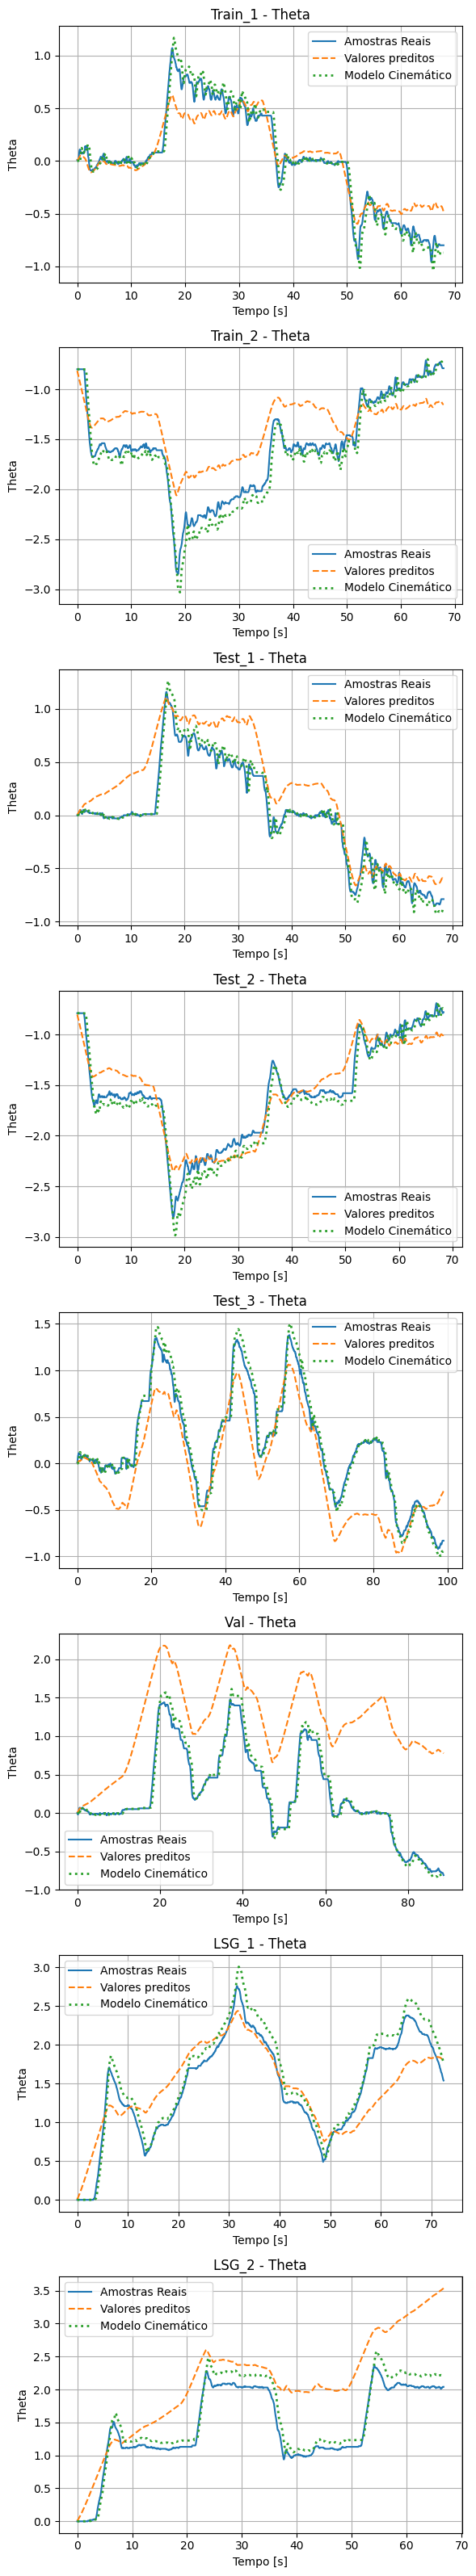

In [10]:
metrics = EvalModel(model)
row